# Lista resolvida - Modelagem Computacional

Este notebook resolve as 20 questões da lista em PDF.  
As implementações usam `numpy`, `sympy`, `scipy` e `matplotlib` quando conveniente.


In [1]:

import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import optimize, linalg, interpolate, integrate
import sympy as sp

np.set_printoptions(precision=8, suppress=True)

def bisection(f, a, b, tol=1e-6, max_iter=200):
    fa, fb = f(a), f(b)
    if fa*fb > 0:
        raise ValueError("Intervalo inválido para bisseção.")
    hist = []
    for k in range(1, max_iter+1):
        c = (a+b)/2
        fc = f(c)
        hist.append((k, a, b, c, fc))
        if abs(fc) < tol or abs(b-a)/2 < tol:
            return c, hist
        if fa*fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, hist

def false_position(f, a, b, tol=1e-6, max_iter=200):
    fa, fb = f(a), f(b)
    if fa*fb > 0:
        raise ValueError("Intervalo inválido para falsa posição.")
    hist = []
    c = None
    for k in range(1, max_iter+1):
        c_prev = c
        c = (a*fb - b*fa)/(fb-fa)
        fc = f(c)
        hist.append((k, a, b, c, fc))
        if abs(fc) < tol or (c_prev is not None and abs(c-c_prev) < tol):
            return c, hist
        if fa*fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, hist

def newton(f, df, x0, tol=1e-6, max_iter=100):
    x = x0
    hist = []
    for k in range(1, max_iter+1):
        fx = f(x)
        dfx = df(x)
        x_new = x - fx/dfx
        hist.append((k, x, fx, dfx, x_new))
        if abs(x_new-x) < tol:
            return x_new, hist
        x = x_new
    return x, hist

def secant(f, x0, x1, tol=1e-6, max_iter=100):
    hist = []
    for k in range(1, max_iter+1):
        f0, f1 = f(x0), f(x1)
        x2 = x1 - f1*(x1-x0)/(f1-f0)
        hist.append((k, x0, x1, x2, f(x2)))
        if abs(x2-x1) < tol:
            return x2, hist
        x0, x1 = x1, x2
    return x2, hist

def modified_secant(f, x0, delta=1e-2, tol=1e-6, max_iter=100):
    x = x0
    hist = []
    for k in range(1, max_iter+1):
        fx = f(x)
        denom = f(x + delta*x) - fx if x != 0 else f(x + delta) - fx
        step = fx * (delta*x if x != 0 else delta) / denom
        x_new = x - step
        hist.append((k, x, x_new, f(x_new)))
        if abs(x_new - x) < tol:
            return x_new, hist
        x = x_new
    return x, hist

def newton_system(F, J, x0, tol=1e-10, max_iter=50):
    x = np.array(x0, dtype=float)
    hist = []
    for k in range(1, max_iter+1):
        Fx = np.array(F(x), dtype=float)
        Jx = np.array(J(x), dtype=float)
        s = np.linalg.solve(Jx, -Fx)
        x_new = x + s
        hist.append((k, x.copy(), np.linalg.norm(Fx, ord=np.inf)))
        if np.linalg.norm(s, ord=np.inf) < tol:
            return x_new, hist
        x = x_new
    return x, hist

def jacobi(A, b, x0=None, tol=1e-6, max_iter=500):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.zeros_like(b) if x0 is None else np.array(x0, dtype=float)
    D = np.diag(np.diag(A))
    R = A - D
    Dinv = np.diag(1/np.diag(D))
    hist = []
    for k in range(1, max_iter+1):
        x_new = Dinv @ (b - R @ x)
        err = np.linalg.norm(x_new - x, ord=np.inf)
        hist.append((k, x_new.copy(), err))
        if err < tol:
            return x_new, hist
        x = x_new
    return x, hist

def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=500):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.zeros_like(b) if x0 is None else np.array(x0, dtype=float)
    hist = []
    n = len(b)
    for k in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            s1 = np.dot(A[i,:i], x[:i])
            s2 = np.dot(A[i,i+1:], x_old[i+1:])
            x[i] = (b[i] - s1 - s2)/A[i,i]
        err = np.linalg.norm(x - x_old, ord=np.inf)
        hist.append((k, x.copy(), err))
        if err < tol:
            return x, hist
    return x, hist

def lagrange_eval(xd, yd, x):
    total = 0.0
    n = len(xd)
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - xd[j])/(xd[i]-xd[j])
        total += yd[i]*Li
    return total

def newton_divided_differences(xd, yd):
    xd = np.array(xd, dtype=float)
    coef = np.array(yd, dtype=float)
    n = len(xd)
    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1])/(xd[j:n] - xd[:n-j])
    return coef

def newton_poly_eval(coef, xd, x):
    result = coef[-1]
    for k in range(len(coef)-2, -1, -1):
        result = result*(x - xd[k]) + coef[k]
    return result

def composite_trapezoid(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b-a)/n
    return h*(0.5*y[0] + y[1:-1].sum() + 0.5*y[-1])

def composite_simpson_13(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n deve ser par.")
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b-a)/n
    return h/3*(y[0] + y[-1] + 4*y[1:-1:2].sum() + 2*y[2:-2:2].sum())

def simpson_38(f, a, b, n=3):
    if n % 3 != 0:
        raise ValueError("n deve ser múltiplo de 3.")
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b-a)/n
    s = y[0] + y[-1]
    for i in range(1, n):
        s += 2*y[i] if i % 3 == 0 else 3*y[i]
    return 3*h*s/8

def euler(f, t0, y0, h, n):
    t = np.zeros(n+1); y = np.zeros(n+1)
    t[0], y[0] = t0, y0
    for i in range(n):
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h*f(t[i], y[i])
    return t, y

def rk2(f, t0, y0, h, n):
    t = np.zeros(n+1); y = np.zeros(n+1)
    t[0], y[0] = t0, y0
    for i in range(n):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h/2, y[i] + h*k1/2)
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h*k2
    return t, y

def rk4(f, t0, y0, h, n):
    t = np.zeros(n+1); y = np.zeros(n+1)
    t[0], y[0] = t0, y0
    for i in range(n):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h/2, y[i] + h*k1/2)
        k3 = f(t[i] + h/2, y[i] + h*k2/2)
        k4 = f(t[i] + h, y[i] + h*k3)
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return t, y

def rk3_scalar(f, t0, y0, h, n):
    t = np.zeros(n+1); y = np.zeros(n+1)
    t[0], y[0] = t0, y0
    for i in range(n):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + h/2, y[i] + h*k1/2)
        k3 = f(t[i] + h, y[i] - h*k1 + 2*h*k2)
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h*(k1 + 4*k2 + k3)/6
    return t, y

def rk4_system(f, t0, y0, h, n):
    t = np.zeros(n+1)
    y = np.zeros((n+1, len(y0)))
    t[0] = t0
    y[0] = np.array(y0, dtype=float)
    for i in range(n):
        k1 = np.array(f(t[i], y[i]))
        k2 = np.array(f(t[i]+h/2, y[i]+h*k1/2))
        k3 = np.array(f(t[i]+h/2, y[i]+h*k2/2))
        k4 = np.array(f(t[i]+h, y[i]+h*k3))
        t[i+1] = t[i] + h
        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return t, y


Matplotlib is building the font cache; this may take a moment.


## Questão 1

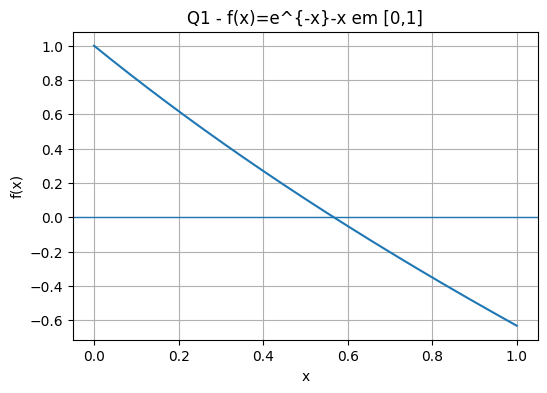

Bisseção: raiz = 0.56714344, iterações = 20
Falsa posição: raiz = 0.56714338, iterações = 7
Newton-Raphson: raiz = 0.56714329, iterações = 3


In [2]:

f = lambda x: np.exp(-x) - x
df = lambda x: -np.exp(-x) - 1

x = np.linspace(0, 1, 300)
plt.figure(figsize=(6,4))
plt.plot(x, f(x))
plt.axhline(0, linewidth=1)
plt.title("Q1 - f(x)=e^{-x}-x em [0,1]")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True)
plt.show()

root_bis, hb = bisection(f, 0, 1)
root_fp, hfp = false_position(f, 0, 1)
root_newt, hn = newton(f, df, 0.5)

print(f"Bisseção: raiz = {root_bis:.8f}, iterações = {len(hb)}")
print(f"Falsa posição: raiz = {root_fp:.8f}, iterações = {len(hfp)}")
print(f"Newton-Raphson: raiz = {root_newt:.8f}, iterações = {len(hn)}")


## Questão 2

In [3]:

f = lambda x: x**3 - 5*x - 1
r_sec, hs = secant(f, 2.0, 2.5)
r_ms1, hm1 = modified_secant(f, 2.0, delta=0.01)
r_ms2, hm2 = modified_secant(f, 2.0, delta=0.05)

print(f"Secante: raiz = {r_sec:.8f}, iterações = {len(hs)}")
print(f"Secante modificada (delta=0.01): raiz = {r_ms1:.8f}, iterações = {len(hm1)}")
print(f"Secante modificada (delta=0.05): raiz = {r_ms2:.8f}, iterações = {len(hm2)}")


Secante: raiz = 2.33005874, iterações = 5
Secante modificada (delta=0.01): raiz = 2.33005874, iterações = 6
Secante modificada (delta=0.05): raiz = 2.33005875, iterações = 7


## Questão 3

In [4]:

def F(v):
    x, y = v
    return np.array([x**2 + y**2 - 9, np.exp(x) + y - 1])

def J(v):
    x, y = v
    return np.array([[2*x, 2*y], [np.exp(x), 1]])

sol3, hist3 = newton_system(F, J, [-2.0, 0.9])
res3 = F(sol3)

print("Solução aproximada [x, y] =", sol3)
print("Resíduo =", res3)
print("Norma infinito do resíduo =", np.linalg.norm(res3, ord=np.inf))


Solução aproximada [x, y] = [-2.84825095  0.94205442]
Resíduo = [ 0. -0.]
Norma infinito do resíduo = 1.1102230246251565e-16


## Questão 4

In [5]:

L = 0.15
C = 47e-6
f = lambda w: w*L - 1/(w*C)
df = lambda w: L + 1/(w**2 * C)

w_bis, hb = bisection(f, 100, 1000)
w_newt, hn = newton(f, df, 400)
w_exact = 1/math.sqrt(L*C)
freq = w_newt/(2*math.pi)

print(f"ω por bisseção = {w_bis:.8f} rad/s")
print(f"ω por Newton = {w_newt:.8f} rad/s")
print(f"ω analítico = {w_exact:.8f} rad/s")
print(f"f = {freq:.8f} Hz")


ω por bisseção = 376.62178800 rad/s
ω por Newton = 376.62178858 rad/s
ω analítico = 376.62178858 rad/s
f = 59.94121933 Hz


## Questão 5

In [6]:

A = np.array([[10,-2,1],[-3,12,-2],[1,-2,8]], dtype=float)
b = np.array([27,-61,-21], dtype=float)

x_gauss = np.linalg.solve(A, b)
P, Lm, Um = linalg.lu(A)
x_lu = linalg.solve_triangular(Um, linalg.solve_triangular(Lm, P.T@b, lower=True))

print("Solução por Gauss =", x_gauss)
print("Solução por LU    =", x_lu)
print("Diferença =", np.linalg.norm(x_gauss - x_lu, ord=np.inf))


Solução por Gauss = [ 2.06666667 -5.26666667 -4.2       ]
Solução por LU    = [ 2.06666667 -5.26666667 -4.2       ]
Diferença = 4.440892098500626e-16


## Questão 6

In [7]:

A = np.array([[4,-1,1],[-2,6,1],[1,1,5]], dtype=float)
b = np.array([7,9,-6], dtype=float)

xj, hj = jacobi(A, b, tol=1e-6)
xgs, hgs = gauss_seidel(A, b, tol=1e-6)

print("Gauss-Jacobi:", xj, "iterações =", len(hj))
print("Gauss-Seidel:", xgs, "iterações =", len(hgs))


Gauss-Jacobi: [ 3.08247345  2.92783426 -2.40206119] iterações = 20
Gauss-Seidel: [ 3.08247414  2.927835   -2.40206183] iterações = 12


## Questão 7

In [8]:

A = np.array([[7,-2,1],[-2,8,-2],[1,-2,6]], dtype=float)
b = np.array([3,-5,4], dtype=float)
x = np.linalg.solve(A, b)
r = b - A@x
cond_inf = np.linalg.cond(A, np.inf)
Ainv_inf = np.linalg.norm(np.linalg.inv(A), np.inf)
err_bound = Ainv_inf * np.linalg.norm(r, np.inf)

print("x =", x)
print("resíduo =", r)
print("||r||∞ =", np.linalg.norm(r, np.inf))
print("Estimativa ||e||∞ <=", err_bound)
print("cond∞(A) =", cond_inf)


x = [ 0.23239437 -0.4471831   0.47887324]
resíduo = [0. 0. 0.]
||r||∞ = 0.0
Estimativa ||e||∞ <= 0.0
cond∞(A) = 2.8732394366197185


## Questão 8

In [9]:

A = np.array([[9,-3,-1],[-3,10,-2],[-1,-2,7]], dtype=float)
b = np.array([12,5,8], dtype=float)

x_dir = np.linalg.solve(A, b)
x_it, hit = gauss_seidel(A, b, tol=1e-8)

print("Método direto =", x_dir)
print("Método iterativo (Gauss-Seidel) =", x_it)
print("iterações =", len(hit))
print("erro entre soluções =", np.linalg.norm(x_dir - x_it, ord=np.inf))


Método direto = [2.03339882 1.48133595 1.85658153]
Método iterativo (Gauss-Seidel) = [2.03339882 1.48133595 1.85658153]
iterações = 15
erro entre soluções = 8.012293051251618e-10


## Questão 9

In [10]:

xd = np.array([0,5,10,15,20], dtype=float)
yd = np.array([22,31,45,54,60], dtype=float)
x_eval = 12.0

T_lagr = lagrange_eval(xd, yd, x_eval)
coef = newton_divided_differences(xd, yd)
T_newt = newton_poly_eval(coef, xd, x_eval)

print(f"T(12) por Lagrange = {T_lagr:.8f}")
print(f"T(12) por Newton   = {T_newt:.8f}")


T(12) por Lagrange = 49.35680000
T(12) por Newton   = 49.35680000


## Questão 10

In [11]:

x = np.array([1,2,3,4,5,6], dtype=float)
y = np.array([2.1,4.0,5.9,8.2,10.1,11.8], dtype=float)

coef1 = np.polyfit(x, y, 1)
coef2 = np.polyfit(x, y, 2)
y1 = np.polyval(coef1, x)
y2 = np.polyval(coef2, x)
sse1 = np.sum((y - y1)**2)
sse2 = np.sum((y - y2)**2)

print("Ajuste linear: y = {:.6f}x + {:.6f}".format(coef1[0], coef1[1]))
print("Ajuste quadrático: y = {:.6f}x² + {:.6f}x + {:.6f}".format(*coef2))
print("SSE linear =", sse1)
print("SSE quadrático =", sse2)


Ajuste linear: y = 1.974286x + 0.106667
Ajuste quadrático: y = -0.017857x² + 2.099286x + -0.060000
SSE linear = 0.09676190476190394
SSE quadrático = 0.08485714285714241


## Questão 11

In [12]:

I = np.array([0.5,1.0,1.5,2.0,2.5,3.0], dtype=float)
P = np.array([0.6,2.2,4.8,8.1,12.7,17.6], dtype=float)

# modelo potência P = a I^b
logI, logP = np.log(I), np.log(P)
bpow, loga = np.polyfit(logI, logP, 1)
apow = np.exp(loga)
Ppow = apow * I**bpow
coefq = np.polyfit(I, P, 2)
Pquad = np.polyval(coefq, I)

I0 = 1.8
print("Modelo potência: P = {:.6f} I^{:.6f}".format(apow, bpow))
print("Modelo quadrático: P = {:.6f}I² + {:.6f}I + {:.6f}".format(*coefq))
print("P(1.8) potência =", apow*I0**bpow)
print("P(1.8) quadrático =", np.polyval(coefq, I0))
print("SSE potência =", np.sum((P - Ppow)**2))
print("SSE quadrático =", np.sum((P - Pquad)**2))


Modelo potência: P = 2.215843 I^1.889719
Modelo quadrático: P = 1.750000I² + 0.720714I + -0.230000
P(1.8) potência = 6.728716826077622
P(1.8) quadrático = 6.737285714285717
SSE potência = 0.05127774843473215
SSE quadrático = 0.05835714285714211


## Questão 12

Spline cúbica em x=3: 3.32172131147541
Polinômio global em x=3: 2.700000000000012


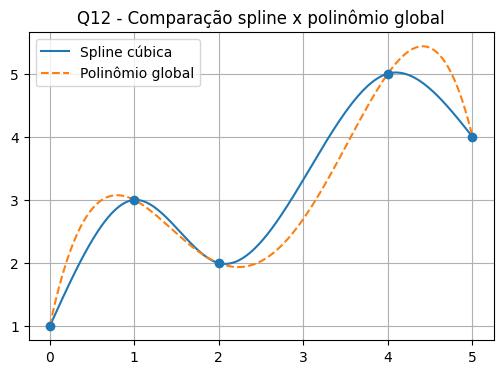

In [13]:

x = np.array([0,1,2,4,5], dtype=float)
y = np.array([1,3,2,5,4], dtype=float)

spline = interpolate.CubicSpline(x, y, bc_type='natural')
xs = np.linspace(0,5,300)
ys = spline(xs)

coef_global = np.polyfit(x, y, len(x)-1)
p_global = np.poly1d(coef_global)

print("Spline cúbica em x=3:", spline(3.0))
print("Polinômio global em x=3:", p_global(3.0))

plt.figure(figsize=(6,4))
plt.plot(xs, ys, label='Spline cúbica')
plt.plot(xs, p_global(xs), label='Polinômio global', linestyle='--')
plt.scatter(x, y, zorder=3)
plt.legend()
plt.grid(True)
plt.title("Q12 - Comparação spline x polinômio global")
plt.show()


## Questão 13

In [14]:

f = lambda x: x**3 + 2*x**2 + 1
exact = 26/3

for n in [2, 4]:
    trap = composite_trapezoid(f, 0, 2, n)
    simp13 = composite_simpson_13(f, 0, 2, n if n % 2 == 0 else n+1)
    print(f"n={n}: Trapézio = {trap:.8f}, erro = {abs(trap-exact):.8e}")
    print(f"n={n}: Simpson 1/3 = {simp13:.8f}, erro = {abs(simp13-exact):.8e}")

simp38 = simpson_38(f, 0, 2, n=3)
print(f"Simpson 3/8 (n=3): {simp38:.8f}, erro = {abs(simp38-exact):.8e}")
print("Integral exata =", exact)


n=2: Trapézio = 13.00000000, erro = 4.33333333e+00
n=2: Simpson 1/3 = 11.33333333, erro = 2.66666667e+00
n=4: Trapézio = 11.75000000, erro = 3.08333333e+00
n=4: Simpson 1/3 = 11.33333333, erro = 2.66666667e+00
Simpson 3/8 (n=3): 11.33333333, erro = 2.66666667e+00
Integral exata = 8.666666666666666


## Questão 14

In [15]:

t = np.array([0,1,2,3,4], dtype=float)
v = np.array([0,3,5,4,2], dtype=float)

trap = np.trapz(v, t)
# Simpson 1/3 com espaçamento uniforme h=1 e 4 subintervalos
h = 1
simp = h/3*(v[0]+v[-1]+4*(v[1]+v[3])+2*v[2])

print("Deslocamento pelo trapézio =", trap)
print("Deslocamento por Simpson 1/3 =", simp)


Deslocamento pelo trapézio = 13.0
Deslocamento por Simpson 1/3 = 13.333333333333332


/tmp/ipykernel_10852/538749628.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trap = np.trapz(v, t)


## Questão 15

In [16]:

f = lambda x: np.exp(-x**2)
exact, _ = integrate.quad(lambda z: np.exp(-z**2), 0, 1)

for n in [2,3,4]:
    xi, wi = np.polynomial.legendre.leggauss(n)
    # mapeamento [-1,1] -> [0,1]
    x = 0.5*(xi + 1)
    val = 0.5*np.sum(wi * f(x))
    print(f"Gauss {n} pontos = {val:.10f}, erro = {abs(val-exact):.3e}")
print("Valor de referência =", exact)


Gauss 2 pontos = 0.7465946883, erro = 2.294e-04
Gauss 3 pontos = 0.7468145842, erro = 9.549e-06
Gauss 4 pontos = 0.7468244681, erro = 3.353e-07
Valor de referência = 0.7468241328124271


## Questão 16

In [17]:

f = lambda t: 12*np.exp(-0.5*t)*np.sin(3*t)**2
exact, _ = integrate.quad(lambda z: 12*np.exp(-0.5*z)*np.sin(3*z)**2, 0, 4)

for n in [8, 16]:
    trap = composite_trapezoid(f, 0, 4, n)
    simp = composite_simpson_13(f, 0, 4, n if n % 2 == 0 else n+1)
    print(f"n={n}: Trapézio = {trap:.8f}, erro = {abs(trap-exact):.3e}")
    print(f"n={n}: Simpson 1/3 = {simp:.8f}, erro = {abs(simp-exact):.3e}")
print("Valor de referência =", exact)


n=8: Trapézio = 10.26610401, erro = 1.536e-01
n=8: Simpson 1/3 = 13.29542089, erro = 2.876e+00
n=16: Trapézio = 10.39277967, erro = 2.690e-02
n=16: Simpson 1/3 = 10.43500488, erro = 1.532e-02
Valor de referência = 10.41968033926953


## Questão 17

In [18]:

f = lambda x, y: x + y
y_exact = lambda x: 2*np.exp(x) - x - 1

for h in [0.2, 0.1]:
    n = int(1/h)
    tE, yE = euler(f, 0, 1, h, n)
    t2, y2 = rk2(f, 0, 1, h, n)
    t4, y4 = rk4(f, 0, 1, h, n)
    ye = y_exact(1.0)
    print(f"h={h}")
    print(f"  Euler: y(1) = {yE[-1]:.8f}, erro = {abs(yE[-1]-ye):.3e}")
    print(f"  RK2  : y(1) = {y2[-1]:.8f}, erro = {abs(y2[-1]-ye):.3e}")
    print(f"  RK4  : y(1) = {y4[-1]:.8f}, erro = {abs(y4[-1]-ye):.3e}")


h=0.2
  Euler: y(1) = 2.97664000, erro = 4.599e-01
  RK2  : y(1) = 3.40541633, erro = 3.115e-02
  RK4  : y(1) = 3.43650227, erro = 6.138e-05
h=0.1
  Euler: y(1) = 3.18748492, erro = 2.491e-01
  RK2  : y(1) = 3.42816169, erro = 8.402e-03
  RK4  : y(1) = 3.43655949, erro = 4.169e-06


## Questão 18

In [19]:

f = lambda t, y: -2*y + 2 - np.exp(-4*t)
y_exact = lambda t: 1 + 0.5*np.exp(-4*t) - 0.5*np.exp(-2*t)

h = 0.2
n = int(2/h)
t2, y2 = rk2(f, 0, 1, h, n)
t4, y4 = rk4(f, 0, 1, h, n)

print("Tabela t, RK2, RK4, exato")
for ti, a, b in zip(t4, y2, y4):
    print(f"{ti:>3.1f}  {a:.8f}  {b:.8f}  {y_exact(ti):.8f}")

print("\nErro global em t=2")
print("RK2:", abs(y2[-1] - y_exact(2)))
print("RK4:", abs(y4[-1] - y_exact(2)))


Tabela t, RK2, RK4, exato
0.0  1.00000000  1.00000000  1.00000000
0.2  0.90593599  0.88960071  0.88950446
0.4  0.89377079  0.87638272  0.87628378
0.6  0.90877294  0.89483774  0.89476187
0.8  0.92943231  0.91948402  0.91943284
1.0  0.94817971  0.94152197  0.94149018
1.2  0.96303936  0.95877430  0.95875590
1.4  0.97409264  0.97145373  0.97144390
1.6  0.98203516  0.98045434  0.98044968
1.8  0.98762762  0.98671315  0.98671143
2.0  0.99151655  0.99101008  0.99100991

Erro global em t=2
RK2: 0.0005066407440738052
RK4: 1.6407124903139447e-07


## Questão 19

In [20]:

k = 0.6
f = lambda t, h: -k*np.sqrt(max(h,0))
h_exact = lambda t: (3 - 0.3*t)**2
t_exact = (3-1)/0.3  # tempo para h=1

step = 0.1
n = int(8/step)
t3, h3 = rk3_scalar(f, 0, 9, step, n)
t4, h4 = rk4(f, 0, 9, step, n)

# interpolação simples do tempo em que h cruza 1
def crossing_time(t, y, target=1.0):
    idx = np.where(y <= target)[0][0]
    t1, t2 = t[idx-1], t[idx]
    y1, y2 = y[idx-1], y[idx]
    return t1 + (target-y1)*(t2-t1)/(y2-y1)

t_rk3 = crossing_time(t3, h3)
t_rk4 = crossing_time(t4, h4)

print("Tempo analítico para h=1:", t_exact)
print("Tempo por RK3:", t_rk3)
print("Tempo por RK4:", t_rk4)


Tempo analítico para h=1: 6.666666666666667
Tempo por RK3: 6.666994975158849
Tempo por RK4: 6.666998364565765


## Questão 20

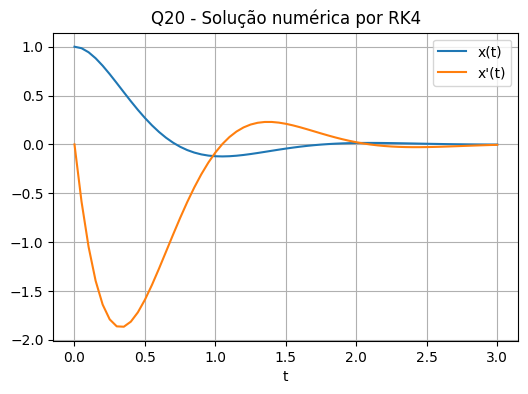

Valores finais em t=3:
x(3)  = -0.001577739777222267
x'(3) = -0.004425859568909203


In [21]:

def f(t, Y):
    x, v = Y
    return np.array([v, -4*v - 13*x])

h = 0.05
n = int(3/h)
t, Y = rk4_system(f, 0, [1,0], h, n)
x = Y[:,0]
v = Y[:,1]

plt.figure(figsize=(6,4))
plt.plot(t, x, label='x(t)')
plt.plot(t, v, label="x'(t)")
plt.grid(True)
plt.legend()
plt.title("Q20 - Solução numérica por RK4")
plt.xlabel("t")
plt.show()

print("Valores finais em t=3:")
print("x(3)  =", x[-1])
print("x'(3) =", v[-1])
